In [1]:
!pip install tensorflow matplotlib

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train shape:", x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)


In [3]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4414 - loss: 1.5283 - val_accuracy: 0.5179 - val_loss: 1.3686
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5894 - loss: 1.1515 - val_accuracy: 0.6173 - val_loss: 1.0716
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6486 - loss: 0.9914 - val_accuracy: 0.6384 - val_loss: 1.0206
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6879 - loss: 0.8929 - val_accuracy: 0.6681 - val_loss: 0.9459
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7199 - loss: 0.8022 - val_accuracy: 0.6919 - val_loss: 0.8905


In [5]:
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("Training Accuracy:", train_acc * 100)
print("Test Accuracy:", test_acc * 100)

Training Accuracy: 74.73599910736084
Test Accuracy: 69.19000148773193


In [6]:
# Get first Conv layer weights
filters, biases = model.layers[0].get_weights()

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 3, 32)


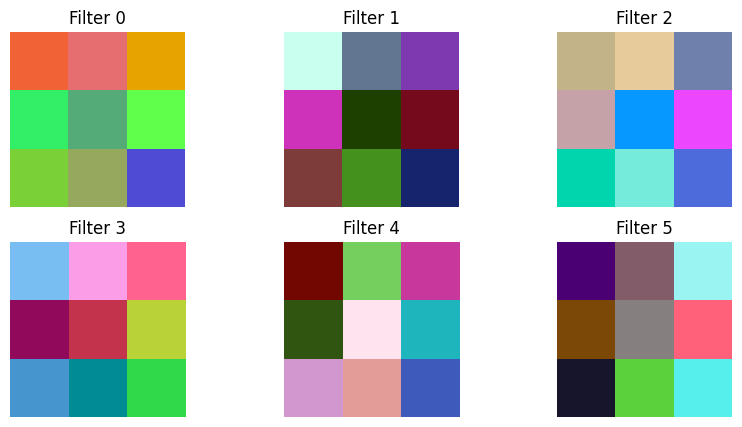

In [7]:
n_filters = 6

plt.figure(figsize=(10,5))

for i in range(n_filters):
    f = filters[:, :, :, i]

    # Normalize
    f = (f - f.min()) / (f.max() - f.min())

    plt.subplot(2, 3, i+1)
    plt.imshow(f)
    plt.axis('off')
    plt.title(f"Filter {i}")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step


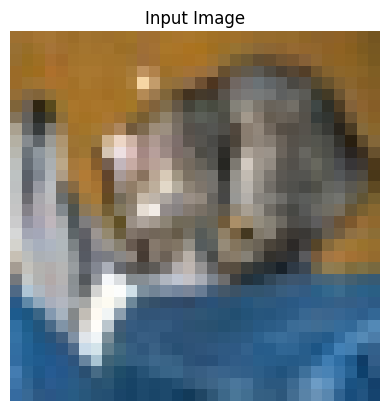

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step

Feature Maps - Layer 1


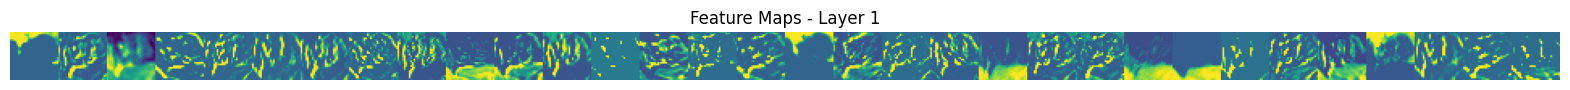


Feature Maps - Layer 2


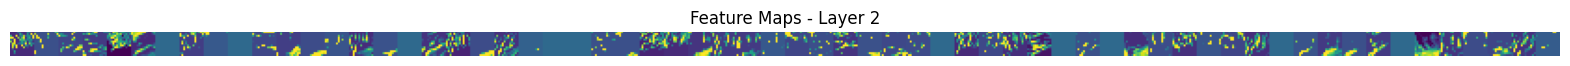


Feature Maps - Layer 3


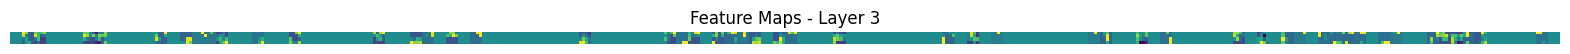

In [12]:
# ============================
# FEATURE MAP VISUALIZATION (FIXED)
# ============================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers


_ = model.predict(x_test[:1])

# 1. Extract Conv layer outputs
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, layers.Conv2D)]

activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

# 2. Select one test image
img = x_test[0]

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Add batch dimension
img = np.expand_dims(img, axis=0)

# 3. Get feature maps
feature_maps = activation_model.predict(img)

# 4. Plot feature maps
for layer_index, feature_map in enumerate(feature_maps):

    print(f"\nFeature Maps - Layer {layer_index+1}")

    n_features = feature_map.shape[-1]
    size = feature_map.shape[1]

    display_grid = np.zeros((size, size * n_features))

    for i in range(n_features):
        x = feature_map[0, :, :, i]

        x -= x.mean()
        x /= (x.std() + 1e-5)
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')

        display_grid[:, i * size : (i + 1) * size] = x

    scale = 20. / n_features

    plt.figure(figsize=(scale * n_features, scale))
    plt.title(f"Feature Maps - Layer {layer_index+1}")
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()